### Read the Dataset

In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv("enhanced_forest_fire_dataset.csv")  # change path if needed
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          1887 non-null   int64  
 1   month        1887 non-null   int64  
 2   year         1887 non-null   int64  
 3   Temperature  1887 non-null   float64
 4   RH           1887 non-null   float64
 5   Ws           1887 non-null   float64
 6   Rain         1887 non-null   float64
 7   FFMC         1887 non-null   float64
 8   DMC          1887 non-null   float64
 9   DC           1887 non-null   float64
 10  ISI          1887 non-null   float64
 11  BUI          1887 non-null   float64
 12  FWI          1887 non-null   float64
 13  Classes      1887 non-null   object 
 14  Region       1887 non-null   int64  
dtypes: float64(10), int64(4), object(1)
memory usage: 221.3+ KB


In [37]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000,1887.000000
mean,15.945416,7.463699,2012.465289,31.928564,63.057764,15.576312,0.554107,82.573344,18.238739,72.842183,5.558824,20.085851,7.163275,0.480127
std,8.816660,1.120820,0.498926,3.503318,11.923974,2.534781,1.852848,9.314104,9.451958,34.113963,2.598789,9.867789,3.965726,0.499737
min,1.000000,6.000000,2012.000000,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,6.000000,2012.000000,29.500000,55.000000,14.000000,0.000000,78.900000,11.800000,50.800000,3.900000,13.800000,5.100000,0.000000
50%,16.000000,7.000000,2012.000000,32.000000,63.400000,15.600000,0.000000,83.900000,18.000000,74.000000,5.600000,19.700000,7.000000,0.000000
75%,24.000000,8.000000,2013.000000,34.400000,71.500000,17.200000,0.200000,88.600000,23.800000,92.700000,7.200000,25.700000,8.900000,1.000000
max,31.000000,9.000000,2013.000000,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [38]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [39]:
df = df.fillna(df.mean(numeric_only=True))

In [40]:
df.duplicated().sum()

0

In [41]:
dup=df[df.duplicated()]
dup

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [42]:
df.shape

(1887, 15)

In [43]:
df['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

In [44]:
df['Classes'] = df['Classes'].str.strip()

In [45]:
df['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

In [46]:
df['Classes'].value_counts()

Classes
not fire    1464
fire         423
Name: count, dtype: int64

### Remove Outliers

In [16]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

In [17]:
num_cols

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region'],
      dtype='object')

In [18]:
cat_cols

Index(['Classes'], dtype='object')

In [47]:
for cols in num_cols:
    Q1=df[cols].quantile(0.25)
    Q3=df[cols].quantile(0.75)
    IQR=Q3-Q1
    lb=Q1-1.5*IQR
    ub=Q3+1.5*IQR
    outliers=df[(df[cols]<lb)|(df[cols]>ub)]
    df.drop(outliers.index,axis=0,inplace=True)

In [48]:
df.shape

(1492, 15)

## Data Preprocessing

### Feature Scaling

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and Target
X = df[['Temperature', 'RH', 'Ws', 'Rain',
        'FFMC', 'DMC', 'DC', 'ISI','BUI','FWI']]

y = df['Classes']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

### label Encoding

In [63]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for cols in cat_cols:
    df[cols]=le.fit_transform(df[cols])

In [64]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
5,6,6,2012,31.0,67.0,14.0,0.0,82.6,5.8,22.2,3.1,7.0,2.5,0,0
6,7,6,2012,33.0,54.0,13.0,0.0,88.2,9.9,30.5,6.4,10.9,7.2,0,0
7,8,6,2012,30.0,73.0,15.0,0.0,86.6,12.1,38.3,5.6,13.5,7.1,0,0
9,10,6,2012,28.0,79.0,12.0,0.0,73.2,9.5,46.3,1.3,12.6,0.9,1,0
10,11,6,2012,31.0,65.0,14.0,0.0,84.5,12.5,54.3,4.0,15.8,5.6,0,0


### Feature Selection

In [65]:
 X = df[['Temperature', 'RH', 'Ws', 'Rain',
              'FFMC', 'DMC', 'DC', 'ISI',
              'BUI', 'FWI']]

y = df['Classes']

### Training Testing 

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [54]:
print(X_train.shape)
print(X_test.shape)

(1119, 10)
(373, 10)


### Model Building 

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

### Model Evaluation

Accuracy: 0.9812332439678284
Confusion Matrix:

[[ 74   5]
 [  2 292]]


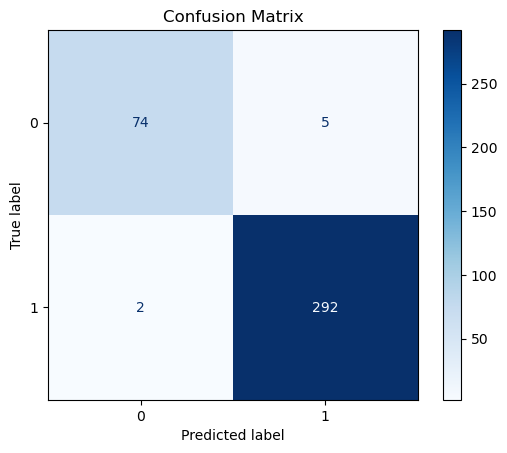

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        79
           1       0.98      0.99      0.99       294

    accuracy                           0.98       373
   macro avg       0.98      0.96      0.97       373
weighted avg       0.98      0.98      0.98       373



In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))

### Dump into Pickle

In [57]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [58]:
print(model.classes_)

[0 1]


In [59]:
print(df['Classes'].value_counts())
print(df['Classes'].unique())

Classes
1    1175
0     317
Name: count, dtype: int64
[0 1]


In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Classes'] = le.fit_transform(df['Classes'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{0: 0, 1: 1}


In [61]:
print(df.groupby('Classes')[[
    'Temperature','RH','FFMC','ISI','FWI'
]].mean())

         Temperature         RH       FFMC       ISI       FWI
Classes                                                       
0          34.489590  54.819874  90.477603  7.212934  9.249842
1          31.197702  65.748255  82.822298  5.398638  6.513787
